## This is the code for generating normalised entropy plot.

By default, if you play this file directly, it will generate the normalised entropy plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists -> Get Samples for each chunk -> Count how many points within each chunk contribute to the top-k -> Compute the normalised entropy based on the distribution -> Plot that

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The Normalized Entropy Plot  

You don't need to change anything else if you only want to produce the entropy plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [37]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

1. Read in the influence lists and define different Ks. You can customize the K you wish to observe here. Change the read_csv file name to your expected files. Remember to map the Train_Size here with your estimation code.

In [38]:
k_lists = [10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

In [39]:
IF_1 = pd.read_csv("Run1/IF_Train_Set_1.csv")
IF_2 = pd.read_csv("Run1/IF_Train_Set_2.csv")
IF_3 = pd.read_csv("Run1/IF_Train_Set_3.csv")
IF_4 = pd.read_csv("Run1/IF_Train_Set_4.csv")
IF_5 = pd.read_csv("Run1/IF_Train_Set_5.csv")
IF_6 = pd.read_csv("Run1/IF_Train_Set_6.csv")
IF_7 = pd.read_csv("Run1/IF_Train_Set_7.csv")
IF_8 = pd.read_csv("Run1/IF_Train_Set_8.csv")
IF_9 = pd.read_csv("Run1/IF_Train_Set_9.csv")
IF_10 = pd.read_csv("Run1/IF_Train_Set_10.csv")

TC_1 = pd.read_csv("Run1/TC_Train_Set_1.csv")
TC_2 = pd.read_csv("Run1/TC_Train_Set_2.csv")
TC_3 = pd.read_csv("Run1/TC_Train_Set_3.csv")
TC_4 = pd.read_csv("Run1/TC_Train_Set_4.csv")
TC_5 = pd.read_csv("Run1/TC_Train_Set_5.csv")
TC_6 = pd.read_csv("Run1/TC_Train_Set_6.csv")
TC_7 = pd.read_csv("Run1/TC_Train_Set_7.csv")
TC_8 = pd.read_csv("Run1/TC_Train_Set_8.csv")
TC_9 = pd.read_csv("Run1/TC_Train_Set_9.csv")
TC_10 = pd.read_csv("Run1/TC_Train_Set_10.csv")

In [40]:
IF_lists = [IF_1, IF_2,IF_3,IF_4,IF_5,IF_6,IF_7,IF_8,IF_9,IF_10]
TC_lists = [TC_1, TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,TC_9,TC_10]
Train_Size = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]

2. Here we get the samples for each chunk, and store them. Basically, we make sure which sample belongs to which chunk.

In [41]:
chunk_list = []
n = len(IF_lists)
for i in range(n - 1, 0, -1):
    curr = IF_lists[i]
    prev = IF_lists[i - 1]
    mask = ~curr["Train_ID"].isin(prev["Train_ID"])
    chunk = curr.loc[mask].copy()
    chunk_list.append(chunk)
core = IF_lists[0].copy()
chunk_list.append(core) 
chunk_list = list(reversed(chunk_list))

In [42]:
print(len(chunk_list))

10


3. Now we compute for Influence Function, how many of points within each chunk contribute to the top-k. 

In [43]:
matrix_lists = []
for k in k_lists:
    rows = []
    for n, df_n in enumerate(IF_lists, start=1):
        top_ids = set(df_n["Train_ID"].head(k))
        for j, ch in enumerate(chunk_list, start=1):
            hits = len(top_ids & set(ch["Train_ID"]))
            rows.append({"Number_of_chunks": n, "count_in_each_chunk": j, "k": k, "hits": hits})
    tidy = pd.DataFrame(rows).sort_values(["Number_of_chunks","count_in_each_chunk"]).reset_index(drop=True)
    matrix = (tidy.pivot(index="Number_of_chunks", columns="count_in_each_chunk", values="hits")
                    .fillna(0).astype(int))
    matrix_lists.append(matrix)

In [44]:
print(matrix_lists[10])

count_in_each_chunk   1    2    3    4   5   6   7   8   9   10
Number_of_chunks                                               
1                    500    0    0    0   0   0   0   0   0   0
2                    251  249    0    0   0   0   0   0   0   0
3                    159  177  164    0   0   0   0   0   0   0
4                    127  123  128  122   0   0   0   0   0   0
5                    113   90  105   95  97   0   0   0   0   0
6                     94   76   85   78  78  89   0   0   0   0
7                     82   68   77   67  68  77  61   0   0   0
8                     78   59   64   65  59  73  52  50   0   0
9                     66   47   60   55  57  62  47  54  52   0
10                    63   44   54   48  48  55  45  40  55  48


4. The following code turns the distribution matrix into the normalized entropy.

In [45]:
scores_lists = []
for matrix in matrix_lists: 
    scores = []
    J = matrix.shape[1]
    for n in range(1, len(matrix) + 1):
        v = matrix.loc[n, list(range(1, n+1))].to_numpy(dtype=float)
        k = v.sum()
        p = v / k
        if n == 1:
            scores.append(1.0)       
        else:
            nz = p > 0 
            H = -(p[nz] * np.log(p[nz])).sum() / np.log(n)
            scores.append(H)
    scores_lists.append(scores)

In [46]:
print(scores_lists[0])

[1.0, 0.7219280948873623, 0.556032649876389, 0.6854752972273345, 0.8277293767706428, 0.8690413667681064, 0.8001978399740513, 0.8154797815570052, 0.7324867603589634, 0.7591760034688151]


In [47]:
Entropy_k_at_10000 = []
for score in scores_lists:
    Entropy_k_at_10000.append(score[-1])

5. Then we plot that

In [48]:
# plt.figure()
# plt.plot(k_lists, Entropy_k_at_10000, marker="o")
# plt.xlabel("Top K")
# plt.ylabel("Entropy @ 10chunks")
# plt.title("IF's Number of Influential Points Vs Confidence of those points")
# plt.xticks(k_lists)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [49]:
# plt.figure()
# plt.plot(k_lists, Entropy_k_at_10000, marker="o")
# plt.xlabel("Top K")
# plt.ylabel("Entropy @ 10chunks")
# plt.title("IF's Number of Influential Points Vs Confidence of those points")
# plt.xticks(k_lists)
# plt.ylim(0.6, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [50]:
IF_Entropy_k_at_10000 = Entropy_k_at_10000
IF_scores_lists = scores_lists

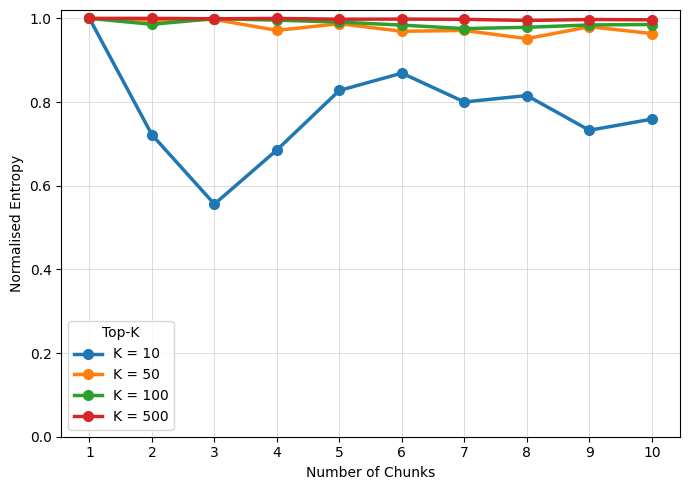

In [51]:
selected_ks = [10, 50, 100, 500]

plt.figure(figsize=(7, 5))

for k in selected_ks:
    k_idx = k_lists.index(k)
    entropy_vs_chunks = scores_lists[k_idx]
    num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

    plt.plot(
        num_chunks,
        entropy_vs_chunks,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=f"K = {k}"
    )

plt.xlabel("Number of Chunks")
plt.ylabel("Normalised Entropy")
plt.xticks(num_chunks)
plt.ylim(0, 1.02)
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(title="Top-K")
plt.tight_layout()

# plt.savefig("Figure7_entropy_vs_chunks.pdf", bbox_inches="tight")
# plt.savefig("Figure7_entropy_vs_chunks.png", dpi=600, bbox_inches="tight")

plt.show()

In [52]:
# selected_k = 10   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [53]:
# selected_k = 50   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [54]:
# selected_k = 100   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [55]:
# selected_k = 500   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

6. Same procedure for TracIn.

In [56]:
chunk_list = []
n = len(TC_lists)
for i in range(n - 1, 0, -1):
    curr = TC_lists[i]
    prev = TC_lists[i - 1]
    mask = ~curr["Train_ID"].isin(prev["Train_ID"])
    chunk = curr.loc[mask].copy()
    chunk_list.append(chunk)
core = TC_lists[0].copy()
chunk_list.append(core) 
chunk_list = list(reversed(chunk_list))

In [57]:
matrix_lists = []
for k in k_lists:
    rows = []
    for n, df_n in enumerate(TC_lists, start=1):
        top_ids = set(df_n["Train_ID"].head(k))
        for j, ch in enumerate(chunk_list, start=1):
            hits = len(top_ids & set(ch["Train_ID"]))
            rows.append({"Number_of_chunks": n, "count_in_each_chunk": j, "k": k, "hits": hits})
    tidy = pd.DataFrame(rows).sort_values(["Number_of_chunks","count_in_each_chunk"]).reset_index(drop=True)
    matrix = (tidy.pivot(index="Number_of_chunks", columns="count_in_each_chunk", values="hits")
                    .fillna(0).astype(int))
    matrix_lists.append(matrix)

In [58]:
print(matrix_lists[10])

count_in_each_chunk   1    2    3    4   5   6   7   8   9   10
Number_of_chunks                                               
1                    500    0    0    0   0   0   0   0   0   0
2                    252  248    0    0   0   0   0   0   0   0
3                    164  163  173    0   0   0   0   0   0   0
4                    122  125  120  133   0   0   0   0   0   0
5                    103   99   97  104  97   0   0   0   0   0
6                     87   80   87   88  76  82   0   0   0   0
7                     72   70   75   75  64  74  70   0   0   0
8                     63   59   68   66  57  66  57  64   0   0
9                     47   50   61   60  54  57  52  54  65   0
10                    38   50   48   52  49  49  47  51  59  57


In [59]:
scores_lists = []
for matrix in matrix_lists: 
    scores = []
    J = matrix.shape[1]
    for n in range(1, len(matrix) + 1):
        v = matrix.loc[n, list(range(1, n+1))].to_numpy(dtype=float)
        k = v.sum()
        p = v / k
        if n == 1:
            scores.append(1.0)       
        else:
            nz = p > 0 
            H = -(p[nz] * np.log(p[nz])).sum() / np.log(n)
            scores.append(H)
    scores_lists.append(scores)

In [60]:
print(scores_lists[0])

[1.0, 0.9709505944546688, 0.9372305632161295, 0.9477309221191609, 0.8488422181524448, 0.8690413667681063, 0.8714392773956555, 0.9073093649624542, 0.9217656864304008, 0.7591760034688149]


In [61]:
Entropy_k_at_10000 = []
for score in scores_lists:
    Entropy_k_at_10000.append(score[-1])

In [62]:
# plt.figure()
# plt.plot(k_lists, Entropy_k_at_10000, marker="o")
# plt.xlabel("Top K")
# plt.ylabel("Entropy @ 10chunks")
# plt.title("TC's Number of Influential Points Vs Confidence of those points")
# plt.xticks(k_lists)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [63]:
# plt.figure()
# plt.plot(k_lists, Entropy_k_at_10000, marker="o")
# plt.xlabel("Top K")
# plt.ylabel("Entropy @ 10chunks")
# plt.title("TC's Number of Influential Points Vs Confidence of those points")
# plt.xticks(k_lists)
# plt.ylim(0.6, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [64]:
TC_Entropy_k_at_10000 = Entropy_k_at_10000
TC_scores_lists = scores_lists

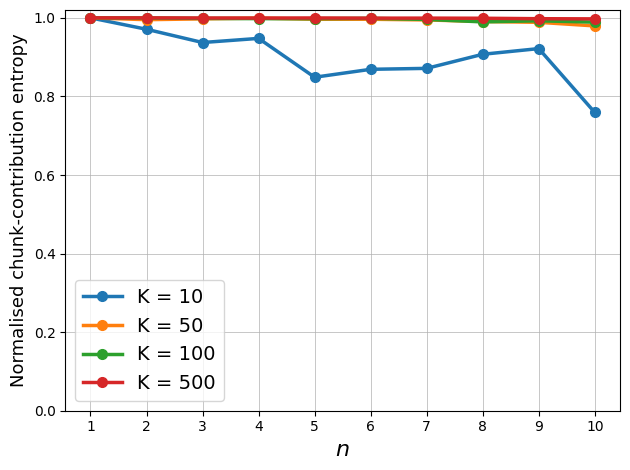

In [65]:
selected_ks = [10, 50, 100, 500]

plt.figure()

for k in selected_ks:
    k_idx = k_lists.index(k)
    entropy_vs_chunks = scores_lists[k_idx]
    num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

    plt.plot(
        num_chunks,
        entropy_vs_chunks,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=f"K = {k}"
    )

plt.xlabel(r"$n$", fontsize=16)
plt.ylabel("Normalised chunk-contribution entropy", fontsize=13)
plt.xticks(num_chunks)
plt.ylim(0, 1.02)
plt.grid(True, linewidth=0.5)
plt.legend(fontsize=14, loc="lower left")
plt.tight_layout()

#plt.savefig("Figure7_entropy_vs_chunks_TC.pdf", bbox_inches="tight")
#plt.savefig("Figure7_entropy_vs_chunks_TC.png", dpi=600, bbox_inches="tight")

plt.show()

In [66]:
# selected_k = 10   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [67]:
# selected_k = 50   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [68]:
# selected_k = 100   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

In [69]:
# selected_k = 500   # choose the k you want to inspect

# k_idx = k_lists.index(selected_k)
# entropy_vs_chunks = scores_lists[k_idx]

# num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

# plt.figure()
# plt.plot(num_chunks, entropy_vs_chunks, marker="o")
# plt.xlabel("Number of Chunks")
# plt.ylabel("Normalized Entropy")
# plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
# plt.xticks(num_chunks)
# plt.ylim(0, 1)
# plt.grid(True, linewidth=0.5)
# plt.show()

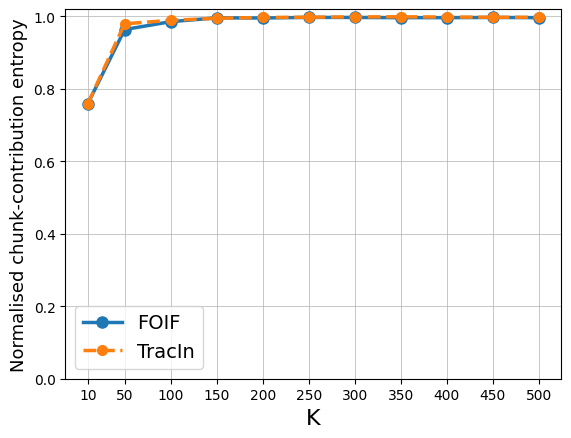

In [70]:
plt.figure()
plt.plot(k_lists, IF_Entropy_k_at_10000, "-o", label = "FOIF",linewidth=2.5,markersize=8)
plt.plot(k_lists, TC_Entropy_k_at_10000, "--o", label = "TracIn",linewidth=2.5,markersize=7)
plt.xlabel("K", fontsize=16)
plt.ylabel("Normalised chunk-contribution entropy", fontsize=13)

plt.legend(fontsize=14, loc="lower left")
plt.xticks(k_lists)
plt.ylim(0, 1.02)
plt.grid(True, linewidth=0.5)

# plt.savefig(
#     "Normalised_Entropy_FOIF_TracIn.png",
#     dpi=600,
#     bbox_inches="tight"
# )
plt.show()

In [71]:
run_id = 1  # change to 2,3,4,5 for each run

result_df = pd.DataFrame({
    "Top K": k_lists,
    "FOIF Entropy": IF_Entropy_k_at_10000,
    "TracIn Entropy": TC_Entropy_k_at_10000
})

result_df.to_csv(f"Entropy_Run_{run_id}.csv", index=False)

In [72]:
records = []

for k in selected_ks:
    k_idx = k_lists.index(k)

    if_entropy_vs_chunks = IF_scores_lists[k_idx]
    tc_entropy_vs_chunks = TC_scores_lists[k_idx]

    num_chunks = list(range(1, len(if_entropy_vs_chunks) + 1))

    for n, if_entropy, tc_entropy in zip(
        num_chunks,
        if_entropy_vs_chunks,
        tc_entropy_vs_chunks
    ):
        records.append({
            "n": n,
            "K": k,
            "FOIF Entropy": if_entropy,
            "TracIn Entropy": tc_entropy
        })

run_df = pd.DataFrame(records)

print(run_df)

run_df.to_csv(f"Entropy_vs_chunks_Run_{run_id}.csv", index=False)

     n    K  FOIF Entropy  TracIn Entropy
0    1   10      1.000000        1.000000
1    2   10      0.721928        0.970951
2    3   10      0.556033        0.937231
3    4   10      0.685475        0.947731
4    5   10      0.827729        0.848842
5    6   10      0.869041        0.869041
6    7   10      0.800198        0.871439
7    8   10      0.815480        0.907309
8    9   10      0.732487        0.921766
9   10   10      0.759176        0.759176
10   1   50      1.000000        1.000000
11   2   50      0.995378        0.995378
12   3   50      0.997423        0.997423
13   4   50      0.971326        0.999423
14   5   50      0.987213        0.996379
15   6   50      0.969163        0.996476
16   7   50      0.971058        0.994735
17   8   50      0.951565        0.990728
18   9   50      0.979990        0.988622
19  10   50      0.963679        0.979509
20   1  100      1.000000        1.000000
21   2  100      0.985815        0.999711
22   3  100      0.999366        0